<a href="https://colab.research.google.com/github/TheGamerJNC/BlazePose-tensorflow/blob/master/Tarea_Motivacional_3_Introducci%C3%B3n_a_la_Inteligencia_Artificial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0 - Importar Librerías y Preparar Datasets

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brunogrisci/breast-cancer-gene-expression-cumida")

print("Path to dataset files:", path)

100%|██████████| 61.5M/61.5M [00:00<00:00, 224MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/brunogrisci/breast-cancer-gene-expression-cumida/versions/2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/brunogrisci/breast-cancer-gene-expression-cumida/versions/2/Breast_GSE45827.csv')

print(df['type'].value_counts())

type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64


In [ ]:
X = df.drop(['samples', 'type'], axis=1)
y = df['type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1 - PCA

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

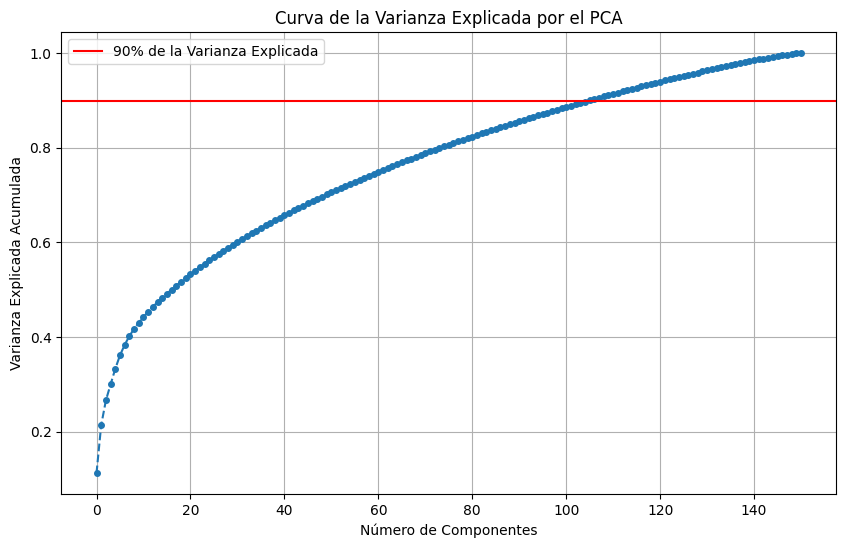

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(varianza_acumulada, marker='o', linestyle='--', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='-', label="90% de la Varianza Explicada")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.title("Curva de la Varianza Explicada por el PCA")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
n_components_90_porciento = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Número de Componentes necesarios para retener el 90% de la varianza = {n_components_90_porciento}")

Número de Componentes necesarios para retener el 90% de la varianza = 106


## PCA - Interpretación
Al observar el screeplot de varianza acumulada, uno se dará cuenta de que se ha seleccionado un umbral del 90%, esto con el objetivo de reducir drásticamente la dimensionalidad del dataset (de más de 54000 genes a unos pocos componentes), siendo logrado lo anterior sin perder la información más crítica, es decir, la que diferencia a los subtipos de cáncer.

# 2 - Loadings

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=X.columns)

# Primeros 5 Loadings['PC1'] (en ordeb descendente) ==> Top 5 genes con mayor impacto (absoluto) en el componente principal 1
top_5_loadings_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(5)

# Primeros 5 Loadings['PC2'] (en orden descendente) ==> Top 5 genes con mayor impacto (absoluto) en el componente principal 2
top_5_loadings_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(5)

print(f'Top 5 genes con mayor impacto en el componente principal 1: \n{top_5_loadings_pc1}')
print(f'\nTop 5 genes con mayor impacto en el componente principal 2: \n{top_5_loadings_pc2}')

Top 5 genes con mayor impacto en el componente principal 1: 
206849_at     0.010768
1560451_at    0.010630
216102_at     0.010621
216114_at     0.010514
234797_at     0.010511
Name: PC1, dtype: float64

Top 5 genes con mayor impacto en el componente principal 2: 
200795_at      0.012263
241777_x_at    0.012084
222358_x_at    0.012062
222282_at      0.012003
232347_x_at    0.011989
Name: PC2, dtype: float64


## Loadings - Interpretación
Como ya sabemos, los loadings representan el "peso" de cada variable original (en este caso, gen) en el componente principal. Los genes con los valores absolutos más altos en los componentes PC1 y PC2 (los componentes 1 y 2 del PCA) son los que más influyen en la mayor dirección de varianza de los datos en sus respectivos componentes, lo que nos dice que éstos podrían ser clave en la separación de las muestras.

# 3 - Visualización de Componentes (por Clase)

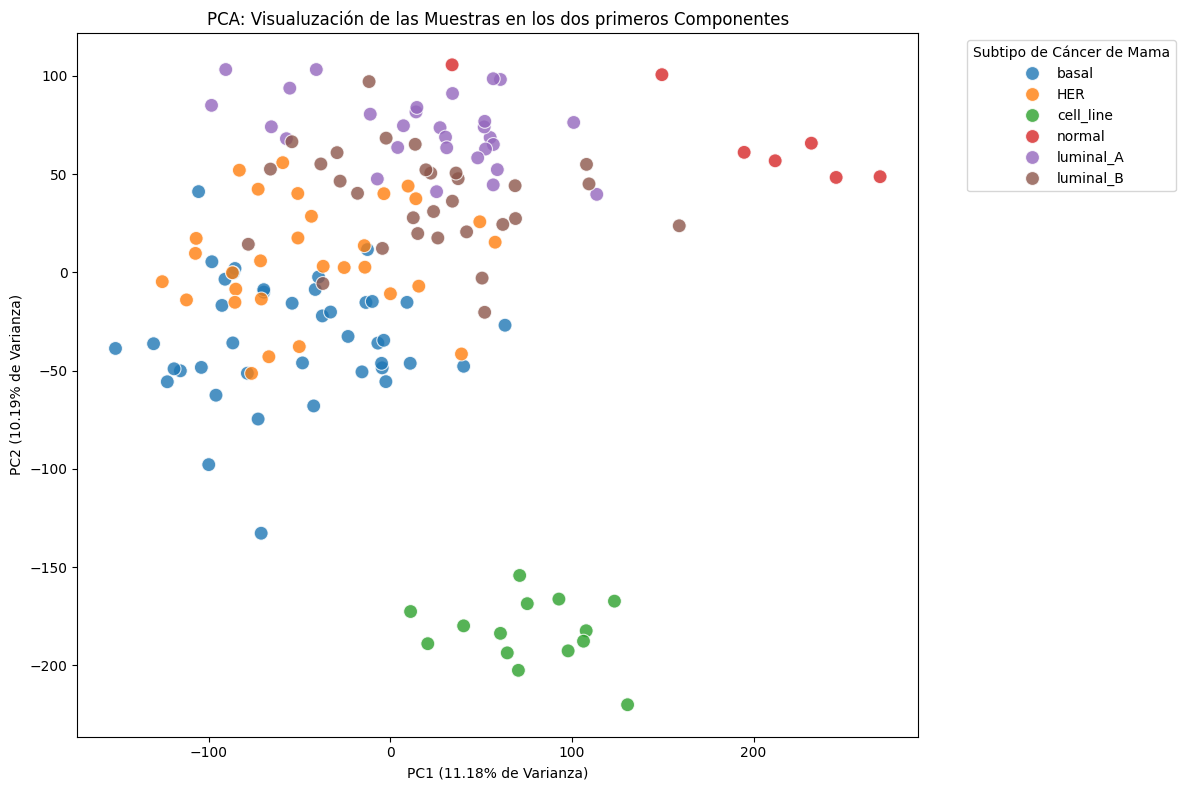

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=100, alpha=0.8)
plt.xlabel(f"PC1 ({varianza_explicada[0]*100:.2f}% de Varianza)")
plt.ylabel(f"PC2 ({varianza_explicada[1]*100:.2f}% de Varianza)")
plt.title("PCA: Visualuzación de las Muestras en los dos primeros Componentes")
plt.legend(title="Subtipo de Cáncer de Mama", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4 - Regresión Lineal (con Grid Search)

In [ ]:
pca_final = PCA(n_components=n_components_90_porciento)
X_reducido = pca_final.fit_transform(X_scaled)

In [ ]:
le = LabelEncoder()
y_codificado = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reducido, y_codificado, test_size=0.2, random_state=42, stratify=y_codificado)

In [ ]:
grilla_hiperparametros = {
    'fit_intercept': [True, False],
    'positive': [False]
}

In [ ]:
lr = LinearRegression()
grid_search = GridSearchCV(estimator=lr, param_grid=grilla_hiperparametros, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")

Mejores Hiperparámetros: {'fit_intercept': True, 'positive': False}


In [ ]:
mejor_modelo = grid_search.best_estimator_
y_pred_continuo = mejor_modelo.predict(X_test)

y_pred_redondeado = np.round(y_pred_continuo).astype(int)
y_pred_redondeado = np.clip(y_pred_redondeado, 0, len(le.classes_) - 1)

y_test_etiquetas = le.inverse_transform(y_test)
y_pred_etiquetas = le.inverse_transform(y_pred_redondeado)

# 5 - Métricas de Clasificación

Accuracy (Exactitud): 0.3226

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

         HER       0.33      0.33      0.33         6
       basal       0.50      0.12      0.20         8
   cell_line       0.00      0.00      0.00         3
   luminal_A       0.50      0.50      0.50         6
   luminal_B       0.43      0.50      0.46         6
      normal       0.17      0.50      0.25         2

    accuracy                           0.32        31
   macro avg       0.32      0.33      0.29        31
weighted avg       0.38      0.32      0.32        31



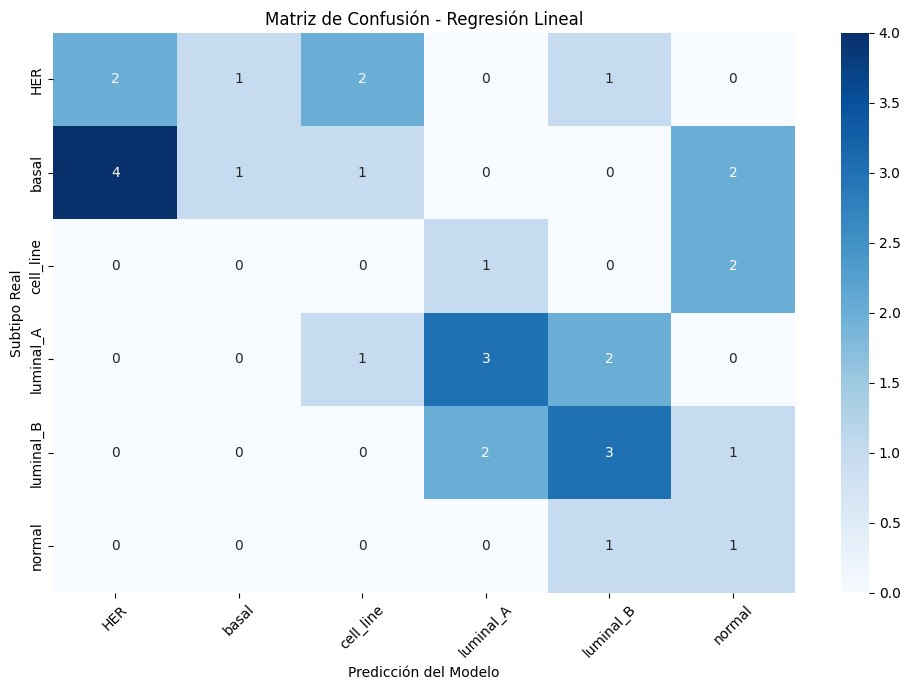

In [ ]:
# 1 - Accuracy
print(f"Accuracy (Exactitud): {accuracy_score(y_test_etiquetas, y_pred_etiquetas):.4f}")

# 2 - Reporte de Clasificación (contiene Precision, Recall y F1-Score)
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test_etiquetas, y_pred_etiquetas, zero_division=0))

# 3 - Matriz de Confusión
cm = confusion_matrix(y_test_etiquetas, y_pred_etiquetas, labels=le.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Subtipo Real')
plt.title('Matriz de Confusión - Regresión Lineal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Métricas de Clasificación - Interpretación
* **Accuracy**: Como esta métrica nos indica qué porcentaje de los casos de prueba cayeron en la clase correcta tras redondear, entonces podemos decir que, de nuestro modelo original, aproximadamente 32.26% de los casos de prueba cayeron en la clase correcta después del redondeo realizado. A pesar que esto se cumpla, cabe destacar que esta métrica NO DEBE SER USADA PARA DIAGNÓSTICOS MÉDICOS, esto debido a que puede ser peligrosamente engañosa. Por ejemplo, si consideramos un caso hipotético en el que el cáncer en una población particular es muy raro (digamos una incidencia del 1%), un modelo que siempre predice que la paciente está sana tendrá un Accuracy del 99%, pero al fin y al cabo será inútil ya que fallará en TODOS los casos positivos.
* **Precision, Recall y F1-Score**: Mientras "Precision y "F1-Score" son métricas que no destacan mucho en casos médicos, el "Recall" es una métrica vital que puede hacer la diferencia entre la vida y la muerte de una paciente. Por ejemplo, el hecho de que en nuestro modelo ni el promedio macro ni el ponderado entreguen un Recall superior al 35% nos dice que éste podría ser muy propenso a entregar falsos negativos (es decir que, en nuestro caso, se le informe a una paciente que está sana cuando en realidad tiene cáncer), lo que le podría generar complicaciones graves o incluso costarle la vida.
* **Matriz de Confusión**: La importancia de la matriz de confusión en casos como este radica en su capacidad patra desglosar los tipos de errores que comete un modelo. Esto se debe a que, en un ámbito como la salud (donde se requiere una gran rigurosidad y seguridad a la hora de hacer un diagnóstico), nos damos cuenta de que no todos los fallos tienen la misma consecuencia. Por ejemplo, no es lo mismo un falso positivo (que podría costar dinero y demandas hacia la clínica por la preocupación generada a la paciente y su círculo cercano) que un falso negativo (que podría costarle LA VIDA a la paciente en cuestión). Aquí es donde entra la matriz de confusión que, al ilustrar de manera clara, concisa y entendible todas las métricas anteriores (accuracy, precision, recall y f1-score), nos permite equilibrar el impacto clínico entre las vidas salvadas y los riesgos asumidos.